Canny Edge Detection

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math

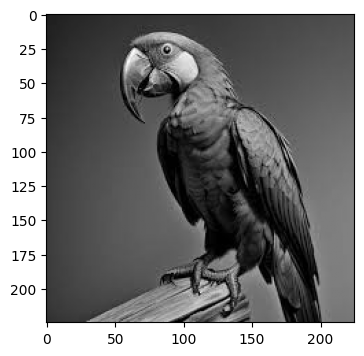

In [5]:
img=cv2.imread(r'E:\BG\bird.jpeg',0)
plt.figure(figsize=(10,4))
plt.imshow(img,cmap='gray')
plt.show()

Applying Gaussian first

In [6]:
def gaussian(x,y,sigma):
    return math.exp(-(x**2+y**2)/(2*sigma**2))

In [7]:
def kernel(size,sigma):
    half=size//2
    kernel,total=[],0.0
    for r in range(size):
            row=[]
            for c in range(size):
                w=gaussian(c-half,r-half,sigma)
                row.append(w)
                total+=w
            kernel.append(row)
    
    normalised=[]
    for r in range(size):
        norm_row=[]
        for c in range(size):
            norm_row.append(kernel[r][c]/total)
        normalised.append(norm_row)
        
    return normalised

In [8]:
def reflect_pad(img,pad):
    h,w=img.shape
    ph,pw=h+2*pad,w+2*pad
    p=np.zeros((ph,pw))
    
    for i in range(h):
        for j in range(w):
            p[i+pad][j+pad]=float(img[i][j])
            
    
    for i in range(pad):
        for j in range(w):
            p[pad-1-i][j+pad]=float(img[i][j])
            p[h+pad+i][j+pad]=float(img[h-1-i][j])
            
    for i in range(ph):
        for j in range(pad):
            p[i][pad-1-j]=p[i][pad+j]
            p[i][pw-pad+j]=p[i][pw-pad-1-j]
    
    return p
    

In [9]:
def apply_gaussian(img,kernel):
    h,w=img.shape
    ksize=len(kernel)
    half=ksize//2
    padded=reflect_pad(img,half)
    output=np.zeros((h,w))
    for i in range(h):
        for j in range(w):
            total=0.0
            for k in range(ksize):
                for l in range(ksize):
                    total+=padded[i+k][j+l]*kernel[k][l]
            output[i][j]=total
    return output

    

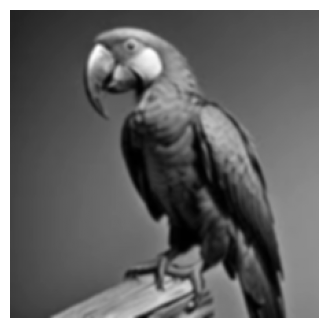

In [10]:
k=kernel(size=5,sigma=1.2)
blurred=apply_gaussian(img,k)
result=np.clip(blurred,0,255).astype(np.uint8)
plt.figure(figsize=(10,4))
plt.imshow(result,cmap='gray')
plt.axis('off')
plt.show()

after gaussian using the sobel

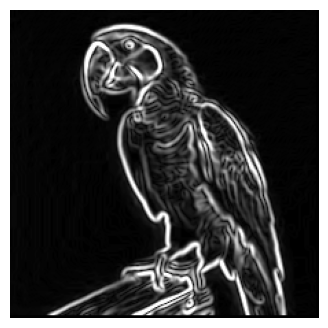

In [11]:
def sobel(img):
    x=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    y=np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
    
    rows,cols=img.shape
    output=np.zeros((rows,cols))
    direction=np.zeros((rows,cols))
    for i in range(rows-2):
        for j in range(cols-2):
            reg=img[i:i+3,j:j+3]
            
            gx=np.sum(reg*x)
            gy=np.sum(reg*y)
            
            output[i,j]=np.sqrt(gx**2+gy**2)
            direction[i, j] = np.arctan2(gy, gx)

    return output,direction

s_img,direction=sobel(result)
s_img=np.clip(s_img,0,255)
s_img=s_img.astype(np.uint8)
plt.figure(figsize=(10,4))
plt.imshow(s_img,cmap='gray')
plt.axis('off')
plt.show()

Non-maximum Suppression

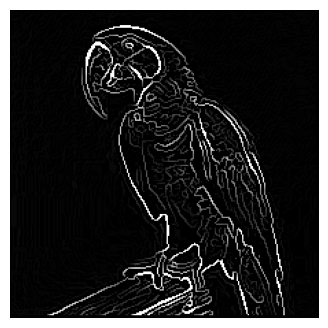

In [12]:
def non_maximum(img,direction):
    h,w=img.shape
    output=np.zeros((h,w))
    angle=direction*180./np.pi
    angle[angle<0]+=180
    for i in range(1,h-1):
        for j in range(1,w-1):
            q=0
            r=0
             # Angle 0°
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = img[i, j+1]
                r = img[i, j-1]

            # Angle 45°
            elif (22.5 <= angle[i,j] < 67.5):
                q = img[i+1, j-1]
                r = img[i-1, j+1]

            # Angle 90°
            elif (67.5 <= angle[i,j] < 112.5):
                q = img[i+1, j]
                r = img[i-1, j]

            # Angle 135°
            elif (112.5 <= angle[i,j] < 157.5):
                q = img[i-1, j-1]
                r = img[i+1, j+1]

            if (img[i,j] >= q) and (img[i,j] >= r):
                output[i,j] = img[i,j]
            else:
                output[i,j] = 0

    return output
nm_img=non_maximum(s_img,direction)
plt.figure(figsize=(10,4))
plt.imshow(nm_img,cmap='gray')
plt.axis('off')
plt.show()


Double Thresholding

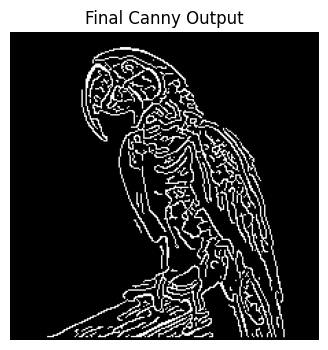

In [ ]:
def double_threshold(img,low_ratio=0.05,high_ratio=0.15):
    high_thresh=img.max()*high_ratio
    low_thresh=high_thresh*low_ratio

    h,w=img.shape
    res=np.zeros((h,w))

    strong=255
    weak=75

    strong_i,strong_j=np.where(img >= high_thresh)
    weak_i,weak_j=np.where((img >= low_thresh) & (img < high_thresh))

    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak

    return res,weak,strong
def hysteresis(img,weak,strong=255):
    h,w=img.shape

    for i in range(1,h-1):
        for j in range(1, w-1):
            if img[i,j]==weak:
                if np.any(img[i-1:i+2,j-1:j+2]==strong):
                    img[i,j]=strong
                else:
                    img[i,j]=0

    return img
dt_img, weak, strong = double_threshold(nm_img)
final_img = hysteresis(dt_img, weak, strong)

plt.figure(figsize=(10,4))
plt.imshow(final_img,cmap='gray')
plt.title("Final Canny Output")
plt.axis('off')
plt.show()